# FP-Growth principal sem autoria para reflexão sobre notícias

Modelo principal: **`sintaxe_ampliada`**, promovido em 7 de outubro de 2026. Usa as tags POS/DEP coletadas em `saida_features/`. As outras variantes são referências e ablações de comparação.
O propósito é acrescentar **observações textuais e perguntas úteis**, conforme o `teste.md` do workspace.

O baseline com autoria e o experimento anterior permanecem preservados. A extração usa os mesmos textos congelados,
IDs/grupos, normalização NFKC e primeiros **300 caracteres** da referência corrigida. POS/DEP usam tokens lexicais;
pontuação usa tokens sem espaço. As taxas dos CSVs completos não são importadas como se tivessem essas definições.

Rótulos e autoria não entram na mineração nem na fila de revisão. As famílias candidatas foram informadas por
análises anteriores, e o teste já foi observado. Este é um experimento exploratório, sem decisão Fake/True para novas notícias.

## 1. Configuração e execução

Use as dependências de `machine-learning/requirements-linguistic.txt`.
Por padrão, o notebook abre o último run concluído deste experimento. Configure `EXISTING_RUN=None` para executar
uma comparação nova, sem sobrescrever resultados anteriores. O corpus congelado deve estar em
`unsupervised-learning/data/Fake.br-Corpus-780f5516c4ae070761632d98ac3368f3ded09d35.zip` e seu SHA-256 é validado.
Há 100 reamostragens de grupos para redescoberta, reaprendendo quantis, e outras 100 para intervalos gramaticais
das regras congeladas na validação. São duas avaliações diferentes.

In [1]:
from pathlib import Path
import sys
import json
import unicodedata
import numpy as np
import pandas as pd
from IPython.display import display, Markdown

search=[Path.cwd().resolve(),*Path.cwd().resolve().parents]
ROOT=next(c for p in search for c in [p,p/'machine-learning',p/'olimpo-fake-news-ai/machine-learning']
          if (c/'unsupervised-learning/fp_growth_principal.py').is_file())
MODULE_DIR=ROOT/'unsupervised-learning'
sys.path.insert(0,str(MODULE_DIR)) if str(MODULE_DIR) not in sys.path else None
import fp_growth_principal as experiment

PRIMARY_VARIANT=experiment.PRIMARY_VARIANT
REPETITIONS=100
runs=list((ROOT/'outputs/model-comparison').glob('fp-growth-metadados-ampliados-*')) + list((ROOT/'outputs/model-comparison').glob('fp-growth-principal-*'))
completed=[p for p in sorted(runs)
           if (p/'run_manifest.json').is_file()
           and json.loads((p/'run_manifest.json').read_text(encoding='utf8')).get('status')=='executed']
EXISTING_RUN=completed[-1] if completed else None
pd.set_option('display.max_colwidth',130)
pd.set_option('display.max_columns',20)

In [2]:
RUN=Path(EXISTING_RUN) if EXISTING_RUN is not None else experiment.run_experiment(repetitions=REPETITIONS)
manifest=json.loads((RUN/'run_manifest.json').read_text(encoding='utf8'))
assert manifest['status']=='executed'
assert PRIMARY_VARIANT in manifest['variants']
display(Markdown(f'**Modelo principal:** `{PRIMARY_VARIANT}`'))
display(Markdown(f'**Run:** `{RUN.name}`'))
display({k:manifest[k] for k in ['corpus','collected_text_alignment_records','bootstrap','review_policy']})

**Modelo principal:** `sintaxe_ampliada`

**Run:** `fp-growth-metadados-ampliados-20261008T002311Z`

{'corpus': {'name': 'Fake.br-Corpus',
  'revision': '780f5516c4ae070761632d98ac3368f3ded09d35',
  'url': 'https://codeload.github.com/roneysco/Fake.br-Corpus/zip/780f5516c4ae070761632d98ac3368f3ded09d35',
  'archive_sha256': 'be91c188f621424017bd79a0f33528dcc27f8a6151adb2bcb899c17719eb4090',
  'expected_sha256': 'be91c188f621424017bd79a0f33528dcc27f8a6151adb2bcb899c17719eb4090',
  'record_count': 7200,
  'labels': {'0': 'True', '1': 'Fake'}},
 'collected_text_alignment_records': 7200,
 'bootstrap': {'repetitions': 100,
  'seed': 42,
  'unit': 'whole canonical paired/exact-duplicate groups',
  'same_training_resamples_across_variants': True,
  'training_quantiles_refitted': True},
 'review_policy': {'labels_used_for_discovery_or_review_ranking': False,
  'min_rediscovery': 0.8,
  'min_validation_occurrences': 100,
  'max_review_candidates': 20,
  'coverage_jaccard_redundancy_threshold': 0.8,
  'human_review_completed': False,
  'display_status': 'research_only',
  'class_comparison_enab

## 2. Quatro representações comparáveis

| Variante | Mudança em relação à anterior |
|---|---|
| `referencia_corrigida` | Estilo corrigido + seis POS + seis DEP; deve reproduzir as 152 regras elegíveis anteriores |
| `pos_ampliado` | Acrescenta ADP, AUX e NUM |
| `sintaxe_ampliada` | Acrescenta obl, cc, acl:relcl e nsubj:pass |
| `metadados_coletados` | Amplia para o vocabulário de tags dos novos CSVs, com exclusões explícitas de diagnósticos |

O conjunto amplo usa o **vocabulário coletado**, não o filtro supervisionado das 31 features.
ADV, ADJ, advmod e ccomp permanecem candidatos. SPACE, dep e ROOT ficam como diagnósticos.
POS_PUNCT e DEP_punct são representadas pela medida de pontuação corrigida. Tags esparsas com quartis coincidentes
são omitidas automaticamente, com motivo registrado. Nenhuma feature recebe um limite a partir da validação ou teste.

In [3]:
pool=pd.read_csv(RUN/'feature_pool.csv')
display(pool)
summary=pd.read_csv(RUN/'variant_summary.csv')
display(Markdown('**Resultado do modelo principal:**'))
display(summary.loc[summary.variant.eq(PRIMARY_VARIANT)])
display(Markdown('**Comparação com referências e ablações:**'))
display(summary)
display(pd.read_csv(RUN/'comparisons.csv'))

,source_feature,feature,selected_in_previous_supervised_eda,included_in_broad_variant,exclusion_reason,denominator
0,POS_ADJ,POS_ADJ_rate,False,True,NaN,tokens_lexical
1,POS_ADP,POS_ADP_rate,True,True,NaN,tokens_lexical
2,POS_ADV,POS_ADV_rate,False,True,NaN,tokens_lexical
3,POS_AUX,POS_AUX_rate,True,True,NaN,tokens_lexical
4,POS_CCONJ,POS_CCONJ_rate,False,True,NaN,tokens_lexical
5,POS_DET,POS_DET_rate,False,True,NaN,tokens_lexical
6,POS_INTJ,POS_INTJ_rate,False,False,tag esparsa: reservar para análise própria,diagnostic_or_separate_measure
7,POS_NOUN,POS_NOUN_rate,True,True,NaN,tokens_lexical
8,POS_NUM,POS_NUM_rate,True,True,NaN,tokens_lexical
9,POS_PART,POS_PART_rate,False,True,NaN,tokens_lexical


**Resultado do modelo principal:**

,variant,candidate_features,active_features,omitted_features,items,eligible_directed_rules,eligible_patterns,validation_pass_rules,test_pass_rules_exploratory,stable_validation_rules,review_candidates,review_candidates_with_added_items,validation_pattern_union_count,validation_added_news_vs_reference,validation_review_union_count
2,sintaxe_ampliada,23,22,1,44,523,345,422,392,347,20,14,1439,65,1346


**Comparação com referências e ablações:**

,variant,candidate_features,active_features,omitted_features,items,eligible_directed_rules,eligible_patterns,validation_pass_rules,test_pass_rules_exploratory,stable_validation_rules,review_candidates,review_candidates_with_added_items,validation_pattern_union_count,validation_added_news_vs_reference,validation_review_union_count
0,referencia_corrigida,16,15,1,30,152,93,121,120,102,20,0,1374,0,1253
1,pos_ampliado,19,18,1,36,189,118,153,154,126,20,5,1410,36,1263
2,sintaxe_ampliada,23,22,1,44,523,345,422,392,347,20,14,1439,65,1346
3,metadados_coletados,50,37,13,74,4350,2546,3563,3474,3093,20,19,1440,66,1393


,variant,new_directed_rules_vs_reference,retained_reference_rules,removed_reference_rules
0,referencia_corrigida,0,152,0
1,pos_ampliado,37,152,0
2,sintaxe_ampliada,371,152,0
3,metadados_coletados,4198,152,0


## 3. Ganho de cobertura e estabilidade

`eligible_directed_rules` conta direções. `eligible_patterns` conta suas uniões distintas.
Regras inversas não viram duas observações independentes. `stable_validation_rules` exige retenção dos filtros na
validação e redescoberta ≥80% no treino. Não equivale a qualidade factual ou à compreensão do usuário.

`validation_added_news_vs_reference` mede notícias adicionais na união de **todos** os padrões elegíveis.
Esse número inclui padrões instáveis e não mede o ganho dos candidatos finais à revisão. A tabela informa separadamente
a cobertura da fila de revisão. Comparar apenas o total de regras pode favorecer duplicações POS/DEP.

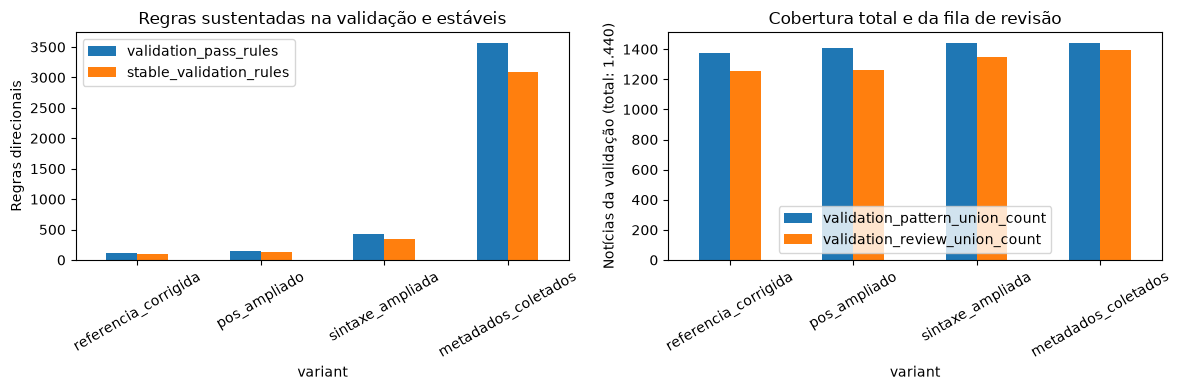

In [4]:
get_ipython().run_line_magic('matplotlib','inline')
import matplotlib.pyplot as plt
fig,axes=plt.subplots(1,2,figsize=(12,4))
summary.plot.bar(x='variant',y=['validation_pass_rules','stable_validation_rules'],ax=axes[0],rot=30)
axes[0].set_title('Regras sustentadas na validação e estáveis')
axes[0].set_ylabel('Regras direcionais')
summary.plot.bar(x='variant',y=['validation_pattern_union_count','validation_review_union_count'],ax=axes[1],rot=30)
axes[1].set_title('Cobertura total e da fila de revisão')
axes[1].set_ylabel('Notícias da validação (total: 1.440)')
plt.tight_layout()
plt.show()

## 4. Candidatos para observações e perguntas

A fila é ordenada por `redescoberta × sqrt(suporte na validação)`, sem rótulos.
Exige pelo menos 100 ocorrências, redescoberta ≥80% e uma direção que mantenha os filtros na validação.
Limita a 20 candidatos, evitando repetição da assinatura das famílias e cobertura com Jaccard ≥0,80.
São critérios exploratórios a avaliar. Família compartilhada sinaliza possível redundância, sem provar dependência exata.

Todos os padrões estão em `research_only`, com comparação por classe desabilitada no catálogo. As observações e perguntas
são rascunhos e precisam de revisão editorial, inclusive para substituir termos sintáticos por explicações acessíveis.

In [5]:
review_tables=[]
for variant in summary.variant:
    t=pd.read_csv(RUN/variant/'review_candidates.csv')
    t.insert(0,'variant',variant)
    review_tables.append(t)
reviews=pd.concat(review_tables,ignore_index=True)
display(reviews[['variant','pattern_text','validation_occurrences','rediscovery_fraction',
                 'contains_added_item','has_structural_overlap','redundancy_family']])
catalogs={v:json.loads((RUN/v/'pattern_catalog.json').read_text(encoding='utf8')) for v in summary.variant}
drafts=[{'variant':v,'patternId':p['patternId'],'observation':p['observationTemplate'],
         'questions':p['reflectionQuestions'],'status':p['displayStatus']}
        for v,c in catalogs.items() for p in c['patterns'] if p['selectionRole']=='review_candidate']
display(pd.DataFrame(drafts).head(12))

,variant,pattern_text,validation_occurrences,rediscovery_fraction,contains_added_item,has_structural_overlap,redundancy_family
0,referencia_corrigida,DEP_advmod_rate_baixo + POS_ADV_rate_baixo,416,1.0,False,True,modificacao_adverbial
1,referencia_corrigida,DEP_amod_rate_baixo + POS_ADJ_rate_baixo,299,1.0,False,True,adjetivacao
2,referencia_corrigida,DEP_ccomp_rate_baixo + DEP_nsubj_rate_baixo,294,1.0,False,False,DEP_ccomp|DEP_nsubj
3,referencia_corrigida,DEP_ccomp_rate_baixo + POS_VERB_rate_baixo,281,1.0,False,False,DEP_ccomp|POS_VERB
4,referencia_corrigida,DEP_advcl_rate_baixo + POS_VERB_rate_baixo,272,1.0,False,False,DEP_advcl|POS_VERB
...,...,...,...,...,...,...,...
75,metadados_coletados,DEP_aux:pass_rate_baixo + POS_AUX_rate_baixo,387,1.0,True,True,auxiliares
76,metadados_coletados,DEP_nsubj:pass_rate_baixo + DEP_nsubj_rate_alto,352,1.0,True,False,DEP_nsubj|DEP_nsubj:pass
77,metadados_coletados,DEP_advcl_rate_baixo + POS_SCONJ_rate_baixo,351,1.0,True,False,DEP_advcl|subordinacao
78,metadados_coletados,DEP_nsubj:pass_rate_baixo + DEP_obj_rate_alto,344,1.0,True,False,DEP_nsubj:pass|DEP_obj


,variant,patternId,observation,questions,status
0,referencia_corrigida,afaef19656e5,"No trecho analisado, as medidas correspondem aos limites de comparação: modificadores adverbiais: valor <= 0; advérbios: valor...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmaçã...",research_only
1,referencia_corrigida,58bd81f28dc3,"No trecho analisado, as medidas correspondem aos limites de comparação: modificadores adjetivais: valor <= 0.0196078; adjetivo...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmaçã...",research_only
2,referencia_corrigida,dcc82376b8a6,"No trecho analisado, as medidas correspondem aos limites de comparação: complementos oracionais: valor <= 0; sujeitos nominais...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmação?]",research_only
3,referencia_corrigida,044b4a18072c,"No trecho analisado, as medidas correspondem aos limites de comparação: complementos oracionais: valor <= 0; verbos: valor <= ...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmação?]",research_only
4,referencia_corrigida,19c77db982d8,"No trecho analisado, as medidas correspondem aos limites de comparação: orações adverbiais: valor <= 0; verbos: valor <= 0.096...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmação?]",research_only
5,referencia_corrigida,11e010b31664,"No trecho analisado, as medidas correspondem aos limites de comparação: orações adverbiais: valor <= 0; modificadores adverbia...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmação?]",research_only
6,referencia_corrigida,b1ddd811a80b,"No trecho analisado, as medidas correspondem aos limites de comparação: orações adverbiais: valor <= 0; nomes próprios: valor ...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmação?]",research_only
7,referencia_corrigida,7313e2f29fbd,"No trecho analisado, as medidas correspondem aos limites de comparação: modificadores adverbiais: valor <= 0; complementos ora...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmaçã...",research_only
8,referencia_corrigida,3624da99214c,"No trecho analisado, as medidas correspondem aos limites de comparação: orações adverbiais: valor <= 0; objetos diretos: valor...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmação?]",research_only
9,referencia_corrigida,757b92cfcc31,"No trecho analisado, as medidas correspondem aos limites de comparação: modificadores adjetivais: valor >= 0.0612245; compleme...","[Qual afirmação deste trecho você gostaria de verificar?, Que fonte ou evidência ajudaria a confirmar ou refutar essa afirmação?]",research_only


## 5. Conferência de exemplos reais

A ocorrência exige **todos** os itens do padrão. A amostra abaixo usa textos da validação que correspondem a novas
combinações da fila de revisão. Os tokens/anotações ajudam a conferir a observação. POS/DEP são previsões do modelo;
várias anotações podem descrever os mesmos tokens. O rótulo não é utilizado para escolher esses exemplos.

In [6]:
records=experiment.base_extraction.load_records(ROOT/'unsupervised-learning/data'/
    f"Fake.br-Corpus-{manifest['corpus']['revision']}.zip")
features=pd.read_csv(RUN/'features.csv',index_col='record_id',float_precision='round_trip')
assignments=pd.read_csv(RUN/'split_assignments.csv').set_index('record_id')
import spacy
nlp=spacy.load('pt_core_news_sm',disable=['ner'])
examples=[]
for variant in ['pos_ampliado','sintaxe_ampliada','metadados_coletados']:
    candidates=reviews.loc[reviews.variant.eq(variant)&reviews.contains_added_item].head(1)
    criteria=pd.read_csv(RUN/variant/'discretization.csv',float_precision='round_trip')
    matrix=experiment.base.apply_discretization(features,criteria)
    for row in candidates.itertuples():
        items=json.loads(row.features)
        ids=matrix.index[matrix[items].all(axis=1)&assignments.partition.reindex(matrix.index).eq('validation')]
        for rid in sorted(ids)[:2]:
            text=unicodedata.normalize('NFKC',records.at[rid,'text']).lstrip('\ufeff')[:300]
            examples.append({'variant':variant,'pattern':row.pattern_text,'record_id':rid,'text':text})
            display(Markdown(f'**{variant} — {rid}**\n\n`{row.pattern_text}`'))
            display(text)
            display(pd.DataFrame([{'token':t.text,'POS':t.pos_,'DEP':t.dep_,
                                   'lexical':not t.is_space and not t.is_punct}
                                  for t in nlp(text)]))
display(pd.DataFrame(examples))

**pos_ampliado — fake/1007**

`DEP_ccomp_rate_baixo + POS_ADP_rate_alto`

'Número de fuzilados durante o regime de Fidel Castro pode ter chegado à casa dos 17 mil.  De acordo com documentos do projeto "Cuba Archive", organizado por cubano-americanos residentes em Nova Jersey, o chamado "Paredón" cubano vitimou ao menos 3.820.  De acordo com a fonte, porém, os fuzilamentos '

,token,POS,DEP,lexical
0,Número,NOUN,nsubj:pass,True
1,de,ADP,case,True
2,fuzilados,NOUN,nmod,True
3,durante,ADP,case,True
4,o,DET,det,True
5,regime,NOUN,nmod,True
6,de,ADP,case,True
7,Fidel,PROPN,nmod,True
8,Castro,PROPN,flat:name,True
9,pode,VERB,ROOT,True


**pos_ampliado — fake/1038**

`DEP_ccomp_rate_baixo + POS_ADP_rate_alto`

'Lula não será preso ... ao menos por enquanto!. .  As penas determinadas pela Justiça em primeira instância só podem ser executadas a partir da confirmação feita pela segunda instância [...] no caso de Lula (especificamente) a 8a Turma do TRF4, que é composta por 3 desembargadores. Lula não irá para'

...

,token,POS,DEP,lexical
0,Relatório,NOUN,nsubj,True
1,assustador,ADJ,amod,True
2,do,ADP,case,True
3,BNDES,PROPN,nmod,True
4,mostra,VERB,ROOT,True
5,dinheiro,NOUN,obj,True
6,público,ADJ,amod,True
7,DO,ADP,case,True
8,BRASIL,PROPN,nsubj,True
9,jorrando,VERB,advcl,True


**metadados_coletados — fake/1012**

`DEP_aux:pass_rate_baixo + DEP_nsubj:pass_rate_baixo`

'Ministro da Defesa não descarta intervenção militar: "Se os políticos não resolverem a crise ...".  Raul Jungmann, ministro da Defesa do governo Temer, não descartou a hipótese de intervenção militar no Brasil.  Sobre os militares, Raul Jungmann disse: A visão que eles têm da crise atual pode ser as'

,token,POS,DEP,lexical
0,Ministro,PROPN,nsubj,True
1,da,ADP,case,True
2,Defesa,PROPN,nmod,True
3,não,ADV,advmod,True
4,descarta,VERB,ROOT,True
5,intervenção,NOUN,obj,True
6,militar,ADJ,amod,True
7,:,PUNCT,punct,False
8,"""",PUNCT,punct,False
9,Se,SCONJ,mark,True


,variant,pattern,record_id,text
0,pos_ampliado,DEP_ccomp_rate_baixo + POS_ADP_rate_alto,fake/1007,Número de fuzilados durante o regime de Fidel Castro pode ter chegado à casa dos 17 mil. De acordo com documentos do projeto ...
1,pos_ampliado,DEP_ccomp_rate_baixo + POS_ADP_rate_alto,fake/1038,Lula não será preso ... ao menos por enquanto!. . As penas determinadas pela Justiça em primeira instância só podem ser execu...
2,sintaxe_ampliada,DEP_acl:relcl_rate_baixo + POS_PRON_rate_baixo,fake/1000,"Relatório assustador do BNDES mostra dinheiro público DO BRASIL jorrando em países comunistas. . Um relatório intitulado ""BND..."
3,sintaxe_ampliada,DEP_acl:relcl_rate_baixo + POS_PRON_rate_baixo,fake/1003,Problema cardíaco tira William Waack do Jornal da Globo. Apresentador será operado amanhã. Waack ficará afastado temporariame...
4,metadados_coletados,DEP_aux:pass_rate_baixo + DEP_nsubj:pass_rate_baixo,fake/1000,"Relatório assustador do BNDES mostra dinheiro público DO BRASIL jorrando em países comunistas. . Um relatório intitulado ""BND..."
5,metadados_coletados,DEP_aux:pass_rate_baixo + DEP_nsubj:pass_rate_baixo,fake/1012,"Ministro da Defesa não descarta intervenção militar: ""Se os políticos não resolverem a crise ..."". Raul Jungmann, ministro da..."


## 6. Composição por classe, separada da descoberta

A descrição por classe e autoria acontece depois de congelar as regras. Dois denominadores:

- Composição Fake: Fake com padrão / todas as ocorrências do padrão.
- Frequência nas Fake: Fake com padrão / todas as Fake da partição/estrato.

Esta execução não estima intervalos da composição por classe. Estratos com poucas ocorrências são sinalizados.
Nada dessas tabelas representa a chance de falsidade de um texto enviado. A composição não influencia o ranking de revisão.

In [7]:
variant=PRIMARY_VARIANT
posthoc=pd.read_csv(RUN/variant/'posthoc_composition.csv')
chosen=reviews.loc[reviews.variant.eq(variant),'pattern_id'].head(5)
display(posthoc.loc[posthoc.pattern_id.isin(chosen)&posthoc.partition.eq('validation'),
                   ['pattern_id','author_state','fake_count','true_count','population_fake','population_true',
                    'composition_fake','frequency_in_fake','frequency_in_true','small_author_stratum']])

,pattern_id,author_state,fake_count,true_count,population_fake,population_true,composition_fake,frequency_in_fake,frequency_in_true,small_author_stratum
3,8715ac5b8fc2,all,185,256,720,720,0.419501,0.256944,0.355556,False
4,8715ac5b8fc2,com_autor,3,252,17,706,0.011765,0.176471,0.356941,False
5,8715ac5b8fc2,sem_autor,182,4,703,14,0.978495,0.258890,0.285714,False
12,afaef19656e5,all,149,267,720,720,0.358173,0.206944,0.370833,False
13,afaef19656e5,com_autor,6,262,17,706,0.022388,0.352941,0.371105,False
14,afaef19656e5,sem_autor,143,5,703,14,0.966216,0.203414,0.357143,False
21,8c3cebc0601d,all,145,242,720,720,0.374677,0.201389,0.336111,False
22,8c3cebc0601d,com_autor,2,235,17,706,0.008439,0.117647,0.332861,False
23,8c3cebc0601d,sem_autor,143,7,703,14,0.953333,0.203414,0.500000,False
30,d1280945c7ef,all,195,157,720,720,0.553977,0.270833,0.218056,False


## 7. Verificações e próximo passo para o produto

O código exige SHA-256 do corpus, correspondência dos 7.200 textos, reconstrução dos grupos e reprodução dos atributos
e regras da referência. A conferência abaixo valida a serialização dos catálogos e as contagens na validação.

O próximo passo é revisar os exemplos e as perguntas das novas famílias. Só depois promover padrões para observações
no motor de insights do `teste.md`, exibindo até três famílias distintas e mantendo a comparação estatística opcional.
A experiência com usuários e uma base externa continuam pendentes.

Resultados ativos em [REGRAS_FP_GROWTH.md](REGRAS_FP_GROWTH.md). A documentação histórica fica nas pastas dos modelos anteriores.

In [8]:
for variant,catalog in catalogs.items():
    criteria=pd.read_csv(RUN/variant/'discretization.csv',float_precision='round_trip')
    matrix=experiment.base.apply_discretization(features,criteria)
    validation=assignments.partition.reindex(matrix.index).eq('validation')
    assert len({p['patternId'] for p in catalog['patterns']})==len(catalog['patterns'])
    for p in catalog['patterns']:
        assert p['displayStatus']=='research_only' and p['comparisonEnabled'] is False
        items=[x['item'] for x in p['items']]
        observed=int((matrix[items].all(axis=1)&validation).sum())
        expected=next(c['occurrences'] for c in p['classComparison']
                      if c['partition']=='validation' and c['author_state']=='all')
        assert observed==expected
display(Markdown('Catálogos e contagens conferidos. Leia o resumo da execução abaixo.'))
display(Markdown((RUN/'summary.md').read_text(encoding='utf8')))

Catálogos e contagens conferidos. Leia o resumo da execução abaixo.

# FP-Growth com metadados ampliados

Extração dos atributos coletados na janela de 300 caracteres, com denominadores corrigidos. As 152 regras direcionais da referência foram reproduzidas. Os 7.200 textos coletados foram conferidos contra o ZIP congelado validado por SHA-256.

Redescoberta em 100 reamostragens dos grupos do treino, com quantis reaprendidos. Intervalos gramaticais na validação reamostram grupos com regras/limites congelados. Teste exploratório.

| Variante | Features ativas | Regras treino | Regras válidas na validação | Estáveis e válidas | Padrões elegíveis | Candidatos à revisão | Notícias adicionais vs referência |
|---|---:|---:|---:|---:|---:|---:|---:|
| referencia_corrigida | 15 | 152 | 121 | 102 | 93 | 20 | 0 |
| pos_ampliado | 18 | 189 | 153 | 126 | 118 | 20 | 36 |
| sintaxe_ampliada | 22 | 523 | 422 | 347 | 345 | 20 | 65 |
| metadados_coletados | 37 | 4350 | 3563 | 3093 | 2546 | 20 | 66 |

A última coluna compara a união de todos os padrões elegíveis. Não mede ganho de cobertura de padrões estáveis nem eficácia das perguntas.
A lista de revisão exige regras sustentadas na validação, ≥100 ocorrências e redescoberta ≥80%. O score usa estabilidade × raiz do suporte, sem label. Ela evita repetir assinaturas de famílias e coberturas com Jaccard ≥0,80. Esses cortes são uma política exploratória, não validação de utilidade do produto.

## Exemplos de novas combinações para revisão

| Variante | Padrão | Ocorrências validação | Redescoberta | Sobreposição estrutural POS/DEP |
|---|---|---:|---:|---|
| pos_ampliado | `DEP_ccomp_rate_baixo + POS_ADP_rate_alto` | 264 | 100% | False |
| pos_ampliado | `DEP_ccomp_rate_baixo + POS_AUX_rate_baixo` | 255 | 100% | False |
| pos_ampliado | `DEP_ccomp_rate_baixo + POS_NUM_rate_alto` | 247 | 100% | False |
| pos_ampliado | `DEP_advcl_rate_baixo + POS_ADP_rate_alto` | 243 | 100% | False |
| pos_ampliado | `DEP_advcl_rate_baixo + POS_NUM_rate_alto` | 224 | 100% | False |
| sintaxe_ampliada | `DEP_acl:relcl_rate_baixo + POS_PRON_rate_baixo` | 441 | 100% | False |
| sintaxe_ampliada | `DEP_nsubj:pass_rate_baixo + POS_AUX_rate_baixo` | 387 | 100% | False |
| sintaxe_ampliada | `DEP_nsubj:pass_rate_baixo + DEP_nsubj_rate_alto` | 352 | 100% | False |
| sintaxe_ampliada | `DEP_nsubj:pass_rate_baixo + DEP_obj_rate_alto` | 344 | 100% | False |
| sintaxe_ampliada | `DEP_acl:relcl_rate_baixo + DEP_nsubj:pass_rate_baixo + POS_PRON_rate_baixo` | 319 | 100% | False |
| metadados_coletados | `DEP_aux:pass_rate_baixo + DEP_nsubj:pass_rate_baixo` | 965 | 100% | False |
| metadados_coletados | `DEP_advcl_rate_baixo + DEP_aux:pass_rate_baixo + DEP_nsubj:pass_rate_baixo` | 589 | 100% | False |
| metadados_coletados | `DEP_aux:pass_rate_baixo + DEP_nsubj:pass_rate_baixo + DEP_nummod_rate_baixo` | 584 | 100% | False |
| metadados_coletados | `DEP_aux:pass_rate_baixo + DEP_ccomp_rate_baixo + DEP_nsubj:pass_rate_baixo` | 570 | 100% | False |
| metadados_coletados | `DEP_nummod_rate_baixo + POS_NUM_rate_baixo` | 560 | 100% | True |

## Uso no propósito do teste.md

Os catálogos JSON contêm itens com limiares completos, denominadores, proveniência das direções, famílias de redundância, observações e perguntas preliminares. Todos permanecem `research_only` e `comparisonEnabled=false`. Nenhuma regra foi automaticamente aprovada para exibição ao usuário.

As contagens Fake/True estão separadas por partição e autoria em `posthoc_composition.csv`, com frequência em cada classe e composição entre ocorrências. Não representam probabilidade de falsidade de uma notícia nova. As descrições automáticas com termos técnicos exigem tradução/revisão editorial.

Próxima decisão: revisar exemplos das novas famílias e medir quais acrescentam observações compreensíveis. A comparação externa e a avaliação com usuários continuam pendentes. Mais regras não demonstram melhor reflexão nem generalização.
